In [1]:
install.packages("table1")

Installing package into ‘/home/jupyter/.R/library’
(as ‘lib’ is unspecified)



In [2]:
library(bigrquery)
library(knitr)
library(tidyverse)
library(ggplot2)
library("table1")
library("IRdisplay")
bq_auth()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘table1’


The following objects are masked from ‘package:base’:

    units, units<-




In [3]:
data <-bq_dataset_query(query="
SELECT *

 FROM `yhcr-prd-phm-bia-core.CB_1935_AK.src_bmbc_EYFSP_COMG01IMD`"
                       ,x="yhcr-prd-phm-bia-core.CB_1935_AK")

EYFSP <- bq_table_download(data) 

In [4]:
data1 <-bq_dataset_query(query="
select round(avg(count1),5)

from(

SELECT person_id,count(person_id) count1

 FROM `yhcr-prd-phm-bia-core.CB_1935_AK.src_bmbc_EYFSP_COMG01IMD`

 group by person_id)base"
                       ,x="yhcr-prd-phm-bia-core.CB_1935_AK")

EYFSPAVG <- bq_table_download(data1) 

In [5]:
display_jupyter <- function(x) {
  css <- system.file("table1_defaults_1.0/table1_defaults.css", package="table1")
  css <- paste(readLines(css), collapse="\n")
  x <- htmltools::tagList(htmltools::tags$style(css), htmltools::tags$div(class="Rtable1", x))
  IRdisplay::display_html(as.character(x))
}

In [6]:
label(EYFSP$AcademicYear)      <- "Academic Year"

label(EYFSP$FSMEligible)      <- "FSM Eligiblity"
label(EYFSP$ethnic_group)      <- "Ethnic Group"
label(EYFSP$Gender)      <- "Gender"
label(EYFSP$IMD)      <- "Average IMD"

In [7]:
 x<-table1(~ EYFSP$AcademicYear + EYFSP$FSMEligible+ EYFSP$Gender + EYFSP$ethnic_group+EYFSP$IMD|EYFSP$score,data=EYFSP
          ,justify=c("left", "left", rep("center", 5)),format_number = TRUE
          ,caption = "COSEY1: Development & Education -1.2 speech,language & communication.\t Table presenting COMGO1 - Listening and attention results from the Early years foundation stage profile (EYFSP)  "
    
         )

In [51]:
display_jupyter(x)

,1 - Emerging(N=14463),2 - Expected level(N=45842),3 - Exceeded(N=15266),A - Exemption not assessed (N=184),No Data(N=23),Overall(N=75778)
Academic Year,,,,,,
2012/2013,3007 (20.8%),6661 (14.5%),1631 (10.7%),32 (17.4%),0 (0%),11331 (15.0%)
2013/2014,2694 (18.6%),6695 (14.6%),1953 (12.8%),18 (9.8%),0 (0%),11360 (15.0%)
2014/2015,2017 (13.9%),6814 (14.9%),2279 (14.9%),31 (16.8%),0 (0%),11141 (14.7%)
2015/2016,1789 (12.4%),6740 (14.7%),2377 (15.6%),0 (0%),23 (100%),10929 (14.4%)
2016/2017,1777 (12.3%),6540 (14.3%),2417 (15.8%),19 (10.3%),0 (0%),10753 (14.2%)
2017/2018,1714 (11.9%),6382 (13.9%),2218 (14.5%),52 (28.3%),0 (0%),10366 (13.7%)
2018/2019,1465 (10.1%),6010 (13.1%),2391 (15.7%),32 (17.4%),0 (0%),9898 (13.1%)
FSM Eligiblity,,,,,,
Yes,3827 (26.5%),8969 (19.6%),1763 (11.5%),38 (20.7%),6 (26.1%),14603 (19.3%)


In [52]:
OverallTrend1 <- EYFSP %>% select(1,4,6)

PersonalSocial1 <- OverallTrend1 %>%
  group_by(AcademicYear,score) 

PS1<- PersonalSocial1 %>% count(AcademicYear,score)


PS1<- group_by(PS1, AcademicYear) %>% mutate(percent = (n/sum(n))*100)


#PS1<-unique(filter(PS1,result == ))

#PS1<- group_by(PS1, AcademicYear) %>% mutate(percent = (n/sum(n))*100)

PS1<-unique(filter(PS1,score == "2 - Expected level" |score == "3 - Exceeded" ))
PS1 <- PS1 %>% select(1,4)

PS1<- group_by(PS1, AcademicYear) %>% mutate(PctPerYear =(sum(percent)))
PS1 <- PS1 %>% select(1,3)

PS1 <- distinct(PS1)

In [53]:
OVERALL<-ggplot(PS1 , aes(x = AcademicYear, y = PctPerYear,group = 1)) +
#scale_y_continuous( limits=c(0,1))+
  geom_line() +
  geom_point() +
   ggtitle(expression(atop("COS-EY 1: 1.2 Speech, Language & Communication",atop("COMGO1 - Listening and attention results from the Early years foundation stage profile (EYFSP)"), atop(italic("percentage of people achieveing atleast 'Expected' grade"), "")))) +


labs(
       x = "Academic Year",
       y = "Percentage of students per year achieving atleast the expected level") +
scale_y_continuous(labels = function(x) paste0(x, "%"),limits=c(0,100))+
               theme(panel.border = element_blank(),# panel.grid.major = element_blank(),
#panel.grid.minor = element_blank(), 
      axis.line = element_line(colour = "black"),axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))+
geom_text(aes(label = round(PctPerYear,0)), hjust = 0.5,  vjust = -1) +
              
  theme_minimal()

In [54]:
OverallTrend1 <- EYFSP %>% select(1,2,4,6)

PersonalSocial1 <- OverallTrend1 %>%
  group_by(AcademicYear,score,ethnic_group) 

PS1<- PersonalSocial1 %>% count(AcademicYear,score,ethnic_group)


PS1<- group_by(PS1, AcademicYear,ethnic_group) %>% mutate(percent = (n/sum(n))*100)


#PS1<-unique(filter(PS1,result == ))

#PS1<- group_by(PS1, AcademicYear,ethnic_group) %>% mutate(percent = (n/sum(n))*100)

PS1<-unique(filter(PS1,score == "2 - Expected level" |score == "3 - Exceeded" ))
PS1 <- PS1 %>% select(1,3,5)

PS1<- group_by(PS1, AcademicYear,ethnic_group) %>% mutate(PctPerYear =round(sum(percent)),2)
PS1 <- PS1 %>% select(1,2,4)

PS1 <- distinct(PS1)

In [55]:
 ethnicity <- ggplot(PS1 , aes(x = AcademicYear, y = PctPerYear,group = ethnic_group,color = ethnic_group)) +
#scale_y_continuous( limits=c(0,1))+
  geom_line() +
  geom_point() +
   ggtitle(expression(atop("COS-EY 1: 1.2 Speech, Language & Communication", atop(italic("percentage of people achieveing atleast 'Expected' grade"),
                                                                                  atop(italic("By ethnic group")))))) +
  labs(
       x = "Academic Year",
       y = "Percentage of students per year achieving atleast the expected level") +
scale_y_continuous(labels = function(x) paste0(x, "%"),limits=c(0,100))+
               theme(panel.border = element_blank(),# panel.grid.major = element_blank(),
#panel.grid.minor = element_blank(), 
      axis.line = element_line(colour = "black"),axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+
geom_text(aes(label = round(PctPerYear,0)), hjust = 0.75,  vjust = -2) +
                   theme_minimal()+
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1))

In [56]:
#library(tidyr)

    
 # df<-   PS1 %>% pivot_wider(
 #       id_cols = AcademicYear,
  #      names_from = ethnic_group,
 #       values_from = PctPerYear
   # )

#PS2<-tableGrob(df)


In [57]:
OverallTrend1 <- EYFSP %>% select(1,3,4,6)

PersonalSocial1 <- OverallTrend1 %>%
  group_by(AcademicYear,score,Gender) 

PS1<- PersonalSocial1 %>% count(AcademicYear,score,Gender)


PS1<- group_by(PS1, AcademicYear,Gender) %>% mutate(percent = (n/sum(n))*100)
#PS1<-unique(filter(PS1,result == ))

#PS1<- group_by(PS1, AcademicYear,ethnic_group) %>% mutate(percent = (n/sum(n))*100)

PS1<-unique(filter(PS1,score == "2 - Expected level" |score == "3 - Exceeded" ))
PS1 <- PS1 %>% select(1,3,5)

PS1<- group_by(PS1, AcademicYear,Gender) %>% mutate(PctPerYear =round(sum(percent)),2)
PS1 <- PS1 %>% select(1,2,4)

PS1 <- distinct(PS1)
PS1 <-PS1<-unique(filter(PS1,Gender == "Female" |Gender == "Male" ))


In [58]:
 gender <- ggplot(PS1 , aes(x = AcademicYear, y = PctPerYear,group = Gender,color = Gender)) +
#scale_y_continuous( limits=c(0,1))+
  geom_line() +
  geom_point() +
   ggtitle(expression(atop("COS-EY 1: 1.2 Speech, Language & Communication", atop(italic("percentage of people achieveing atleast 'Expected' grade"),
                                                                                  atop(italic("By Gender")))))) +
  labs(
       x = "Academic Year",
       y = "Percentage of students per year achieving atleast the expected level") +
scale_y_continuous(labels = function(x) paste0(x, "%"),limits=c(0,100))+
               theme(panel.border = element_blank(),# panel.grid.major = element_blank(),
#panel.grid.minor = element_blank(), 
      axis.line = element_line(colour = "black"),axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+
geom_text(aes(label = round(PctPerYear,0)), hjust = 0.75,  vjust = -1) +
                   theme_minimal()+
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1))

In [59]:
OverallTrend1 <- EYFSP %>% select(1,9,4,6)

PersonalSocial1 <- OverallTrend1 %>%
  group_by(AcademicYear,score,IMD) 

PS1<- PersonalSocial1 %>% count(AcademicYear,score,IMD)


PS1<- group_by(PS1, AcademicYear,IMD) %>% mutate(percent = (n/sum(n))*100)
#PS1<-unique(filter(PS1,result == ))

#PS1<- group_by(PS1, AcademicYear,ethnic_group) %>% mutate(percent = (n/sum(n))*100)

PS1<-unique(filter(PS1,score == "2 - Expected level" |score == "3 - Exceeded" ))
PS1 <- PS1 %>% select(1,3,5)

PS1<- group_by(PS1, AcademicYear,IMD) %>% mutate(PctPerYear =round(sum(percent)),2)
PS1 <- PS1 %>% select(1,2,4)

PS1 <- distinct(PS1)


In [60]:
 IMD <- ggplot(PS1 , aes(x = AcademicYear, y = PctPerYear,group = IMD,color = IMD)) +
#scale_y_continuous( limits=c(0,1))+
  geom_line() +
  geom_point() +
   ggtitle(expression(atop("COS-EY 1: 1.2 Speech, Language & Communication", atop(italic("percentage of people achieveing atleast 'Expected' grade"),
                                                                                  atop(italic("By IMD")))))) +
  labs(
       x = "Academic Year",
       y = "Percentage of students per year achieving atleast the expected level") +
scale_y_continuous(labels = function(x) paste0(x, "%"),limits=c(0,100))+
               theme(panel.border = element_blank(),# panel.grid.major = element_blank(),
#panel.grid.minor = element_blank(), 
      axis.line = element_line(colour = "black"),axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+
geom_text(aes(label = round(PctPerYear,0)), hjust = 0.75,  vjust = -1) +
                   theme_minimal()+
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1))

In [66]:
library(gridExtra)
plot <- list(OVERALL, gender, IMD, ethnicity)
pdf('1.2 Speech Language and Communication.pdf',width=10, height=10)
  title <- "Plots for 1.2 Speech Language & Communication : COMGO1 Communication and Language - Listening and attention"
#grid.text(title) 
plot
dev.off()
#

[[1]]

[[2]]

[[3]]

[[4]]


png 
  2

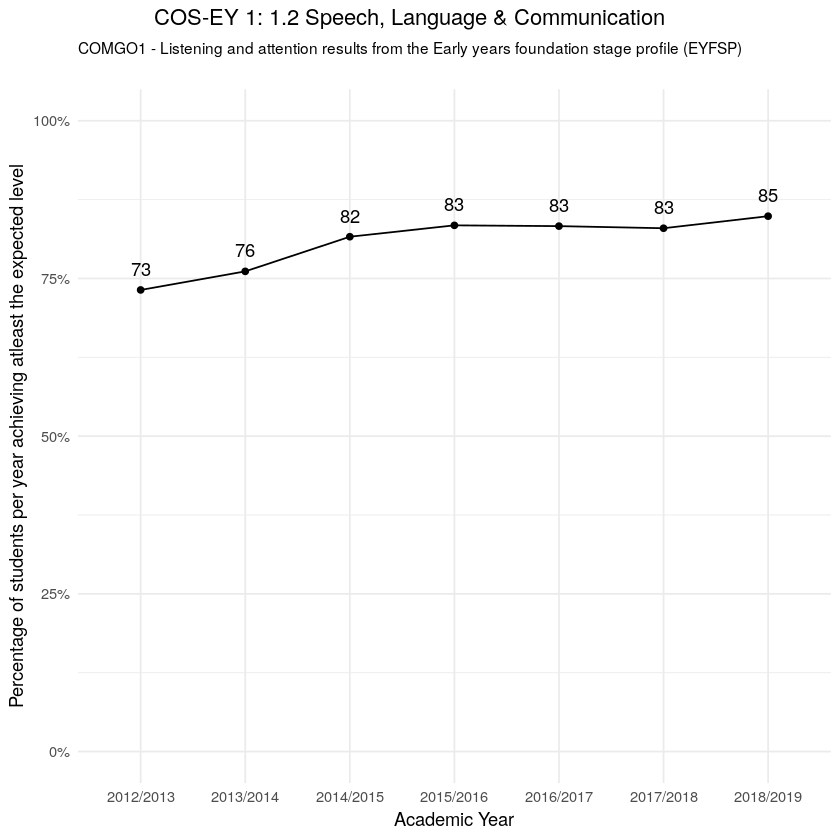

In [50]:
OVERALL